### Understanding Combeacks in EPL Matches

This analysis aims to explore the phenomenon of comebacks in English Premier League (EPL) matches. Specifically, we will investigate how frequently teams that are trailing or drawing at half-time manage to win or draw the match by full-time. We will also examine the probability of home versus away teams achieving a comeback. This analysis will shed light on the dynamics of football matches and provide insights into team performance under pressure.

# An analysis of comebacks in the EPL

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


## Loading data


In [2]:

data = pd.read_csv('/content/merged_22-25.csv')
df = pd.DataFrame(data)
df.head()

,Div,Date,Time,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,...,IWA,VCH,VCD,VCA,IWCH,IWCD,IWCA,VCCH,VCCD,VCCA
0,E0,15/08/2025,20:00,Liverpool,Bournemouth,4,2,H,1,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,E0,16/08/2025,12:30,Aston Villa,Newcastle,0,0,D,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,E0,16/08/2025,15:00,Brighton,Fulham,1,1,D,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,E0,16/08/2025,15:00,Sunderland,West Ham,3,0,H,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,E0,16/08/2025,15:00,Tottenham,Burnley,3,0,H,1,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Inspecting columns

In [3]:
# the list of the column names
column_names = df.columns.tolist()
print(column_names)


['Div', 'Date', 'Time', 'HomeTeam', 'AwayTeam', 'FTHG', 'FTAG', 'FTR', 'HTHG', 'HTAG', 'HTR', 'Referee', 'HS', 'AS', 'HST', 'AST', 'HF', 'AF', 'HC', 'AC', 'HY', 'AY', 'HR', 'AR', 'B365H', 'B365D', 'B365A', 'BFDH', 'BFDD', 'BFDA', 'BMGMH', 'BMGMD', 'BMGMA', 'BVH', 'BVD', 'BVA', 'BWH', 'BWD', 'BWA', 'CLH', 'CLD', 'CLA', 'LBH', 'LBD', 'LBA', 'PSH', 'PSD', 'PSA', 'MaxH', 'MaxD', 'MaxA', 'AvgH', 'AvgD', 'AvgA', 'BFEH', 'BFED', 'BFEA', 'B365>2.5', 'B365<2.5', 'P>2.5', 'P<2.5', 'Max>2.5', 'Max<2.5', 'Avg>2.5', 'Avg<2.5', 'BFE>2.5', 'BFE<2.5', 'AHh', 'B365AHH', 'B365AHA', 'PAHH', 'PAHA', 'MaxAHH', 'MaxAHA', 'AvgAHH', 'AvgAHA', 'BFEAHH', 'BFEAHA', 'B365CH', 'B365CD', 'B365CA', 'BFDCH', 'BFDCD', 'BFDCA', 'BMGMCH', 'BMGMCD', 'BMGMCA', 'BVCH', 'BVCD', 'BVCA', 'BWCH', 'BWCD', 'BWCA', 'CLCH', 'CLCD', 'CLCA', 'LBCH', 'LBCD', 'LBCA', 'PSCH', 'PSCD', 'PSCA', 'MaxCH', 'MaxCD', 'MaxCA', 'AvgCH', 'AvgCD', 'AvgCA', 'BFECH', 'BFECD', 'BFECA', 'B365C>2.5', 'B365C<2.5', 'PC>2.5', 'PC<2.5', 'MaxC>2.5', 'MaxC<2

In [4]:
df.shape

(1441, 162)

### Selecting columns of interest

In [5]:
epl_stats = df[['Date','Time','HomeTeam','AwayTeam','FTHG','FTAG','HTHG','HTAG','FTR']]
epl_stats.head(3)

,Date,Time,HomeTeam,AwayTeam,FTHG,FTAG,HTHG,HTAG,FTR
0,15/08/2025,20:00,Liverpool,Bournemouth,4,2,1,0,H
1,16/08/2025,12:30,Aston Villa,Newcastle,0,0,0,0,D
2,16/08/2025,15:00,Brighton,Fulham,1,1,0,0,D


In [6]:
# check for null values
epl_stats.isnull().sum()

,0
Date,0
Time,0
HomeTeam,0
AwayTeam,0
FTHG,0
FTAG,0
HTHG,0
HTAG,0
FTR,0


In [7]:

epl_stats.dtypes

,0
Date,object
Time,object
HomeTeam,object
AwayTeam,object
FTHG,int64
FTAG,int64
HTHG,int64
HTAG,int64
FTR,object


In [8]:
# Format date to datetime
epl_stats['Date'] = pd.to_datetime(epl_stats['Date'])
epl_stats.dtypes

/tmp/ipykernel_16327/1019933024.py:2: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  epl_stats['Date'] = pd.to_datetime(epl_stats['Date'])
/tmp/ipykernel_16327/1019933024.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  epl_stats['Date'] = pd.to_datetime(epl_stats['Date'])


,0
Date,datetime64[ns]
Time,object
HomeTeam,object
AwayTeam,object
FTHG,int64
FTAG,int64
HTHG,int64
HTAG,int64
FTR,object


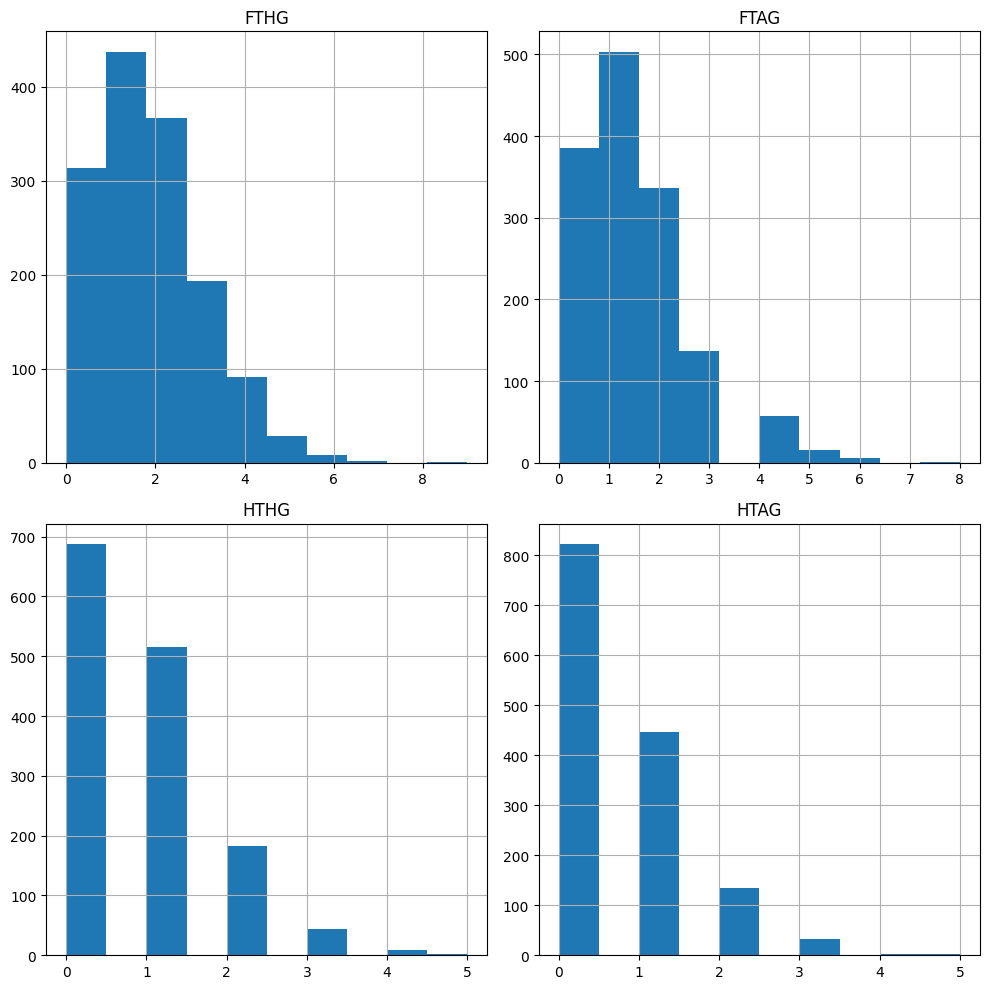

In [9]:
# filter for numeric columns only
numeric_columns = epl_stats.select_dtypes(include=[np.number])

# plot histograms for numeric columns
numeric_columns.hist(figsize=(10, 10))
plt.tight_layout()
plt.show()

### First half scorers

In [10]:
# only retain games with scores in the first half

games_with_half_time_goal = epl_stats[(epl_stats['HTHG'] >= 1) | (epl_stats['HTAG']>=1)].copy()
games_with_half_time_goal.shape

(1069, 9)

## Half time performance

In [11]:
# make a column showing the leader at half time
conditions = [
    games_with_half_time_goal['HTHG'] > games_with_half_time_goal['HTAG'],
    games_with_half_time_goal['HTHG'] < games_with_half_time_goal['HTAG']
]
choices = ['H', 'A']
games_with_half_time_goal['HalfT_leader'] = np.select(conditions, choices, default='D')




In [12]:
# Comparing half time to full time results

conditions2 = [
    (games_with_half_time_goal['HalfT_leader'] == games_with_half_time_goal['FTR']) & (games_with_half_time_goal['FTR'] == 'H'),
    (games_with_half_time_goal['HalfT_leader'] == games_with_half_time_goal['FTR']) & (games_with_half_time_goal['FTR'] == 'A'),
    (games_with_half_time_goal['HalfT_leader'] == games_with_half_time_goal['FTR']) & (games_with_half_time_goal['FTR'] == 'D'),
    (games_with_half_time_goal['HalfT_leader'] != games_with_half_time_goal['FTR']) & (games_with_half_time_goal['FTR'] != 'D'),
]
# come back = when a team is losing in the first half, then ends up winning the match
# Neutral = when there is a leader at half time but match ends at a draw
choices = ['Home','Away','Draw','Come back']
games_with_half_time_goal['Half_vs_Full'] = np.select(conditions2, choices, default='Neutral')

#making a column with true or false if HalfT_leader and FTR are equal or not
conditions3 = [
    (games_with_half_time_goal['HalfT_leader'] == games_with_half_time_goal['FTR']),
    (games_with_half_time_goal['HalfT_leader'] != games_with_half_time_goal['FTR'])
]
choices = [False, True]
games_with_half_time_goal['Changed'] = np.select(conditions3, choices, default='Neutral')
games_with_half_time_goal.head()

,Date,Time,HomeTeam,AwayTeam,FTHG,FTAG,HTHG,HTAG,FTR,HalfT_leader,Half_vs_Full,Changed
0,2025-08-15,20:00,Liverpool,Bournemouth,4,2,1,0,H,H,Home,False
4,2025-08-16,15:00,Tottenham,Burnley,3,0,1,0,H,H,Home,False
5,2025-08-16,17:30,Wolves,Man City,0,4,0,2,A,A,Away,False
7,2025-08-17,14:00,Nott'm Forest,Brentford,3,1,3,0,H,H,Home,False
8,2025-08-17,16:30,Man United,Arsenal,0,1,0,1,A,A,Away,False


Text(0.5, 1.0, 'Number per category for half time vs fulltime')

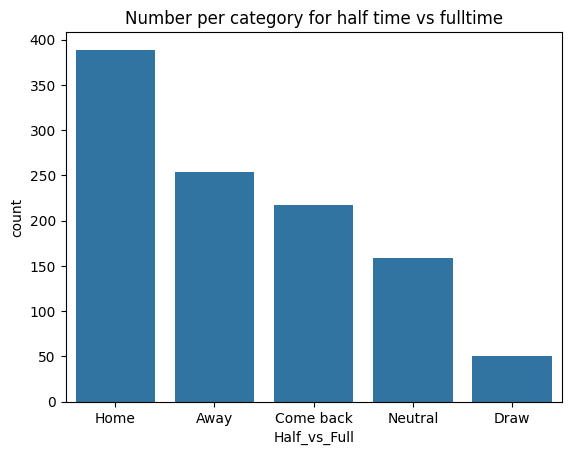

In [13]:
# chart the number of outcomes per Half_vs_Full category
sns.barplot(games_with_half_time_goal['Half_vs_Full'].value_counts()).set_title('Number per category for half time vs fulltime')

Half_vs_Full
Home         0.363891
Away         0.237605
Come back    0.202993
Neutral      0.148737
Draw         0.046773
Name: proportion, dtype: float64


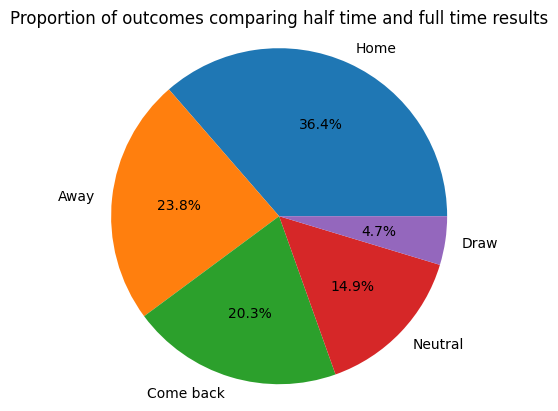

In [14]:
# proportion of outcomes comparing half time and full time results
ratio_of_categories = games_with_half_time_goal['Half_vs_Full'].value_counts(normalize=True).sort_values(ascending = False)
print(ratio_of_categories)

# plot pie chart
plt.pie(ratio_of_categories, labels=ratio_of_categories.index, autopct='%1.1f%%')
plt.title('Proportion of outcomes comparing half time and full time results')
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()



Changed
False    0.648269
True     0.351731
Name: proportion, dtype: float64

64.83% of the games had the half time leader win the match



Text(0.5, 1.0, 'Proportion of games where the leader at half time lost or drawed at full time')

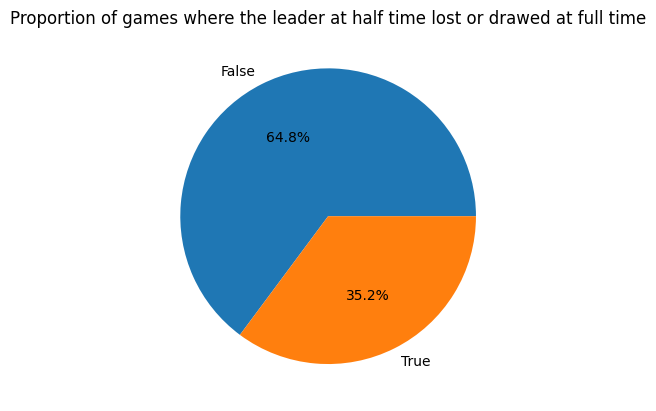

In [15]:
# investigating if the leader at half time also lead at full time
games_with_half_time_goal['Changed'].value_counts()
p_of_change = games_with_half_time_goal['Changed'].value_counts(normalize=True)
print(p_of_change)

print(f'\n{round(p_of_change.iloc[0] *100,2)}% of the games had the half time leader win the match\n')

# Pie chart
plt.pie(p_of_change, labels=p_of_change.index, autopct='%1.1f%%')
plt.title('Proportion of games where the leader at half time lost or drawed at full time')



### P of reversal for home teams

In [16]:
# propotion of comebacks from home team
homes = games_with_half_time_goal.groupby('Half_vs_Full')['FTR'].value_counts(normalize=True)
#print(homes)
print(f'{round(homes.loc['Come back'].loc['H']*100,2)}% of the comebacks were from home teams and {round(homes.loc['Come back'].loc['A']*100,2)}% from the away team.')

55.3% of the comebacks were from home teams and 44.7% from the away team.


In [17]:
# Probability of a home team to have a comeback
p_of_home_T_ComeBack = round(homes.loc[('Come back','H')] * ratio_of_categories['Come back'] * 100,2)
p_of_away_T_ComeBack = round(homes.loc[('Come back','A')] * ratio_of_categories['Come back'] * 100,2)

print(f'The probability of a home team to have a comeback is {p_of_home_T_ComeBack}% and for an away team is {p_of_away_T_ComeBack}%')

The probability of a home team to have a comeback is 11.23% and for an away team is 9.07%


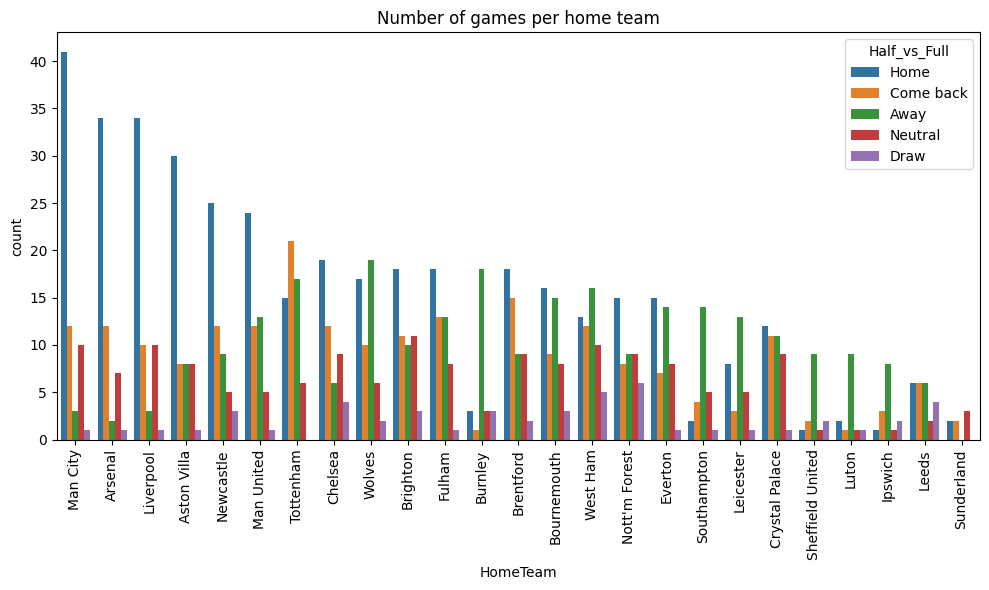

In [18]:
cow = games_with_half_time_goal.groupby('HomeTeam')['Half_vs_Full'].value_counts().sort_values(ascending=False)
# Convert the Series with MultiIndex to a DataFrame
cow_df = cow.reset_index(name='count')

# Plotting with explicit x, y, and hue parameters
plt.figure(figsize=(10, 6))
sns.barplot(data=cow_df, x='HomeTeam', y='count', hue='Half_vs_Full').set_title('Number of games per home team')
plt.xticks(rotation=90) # Rotate x-axis labels for better readability
plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show()

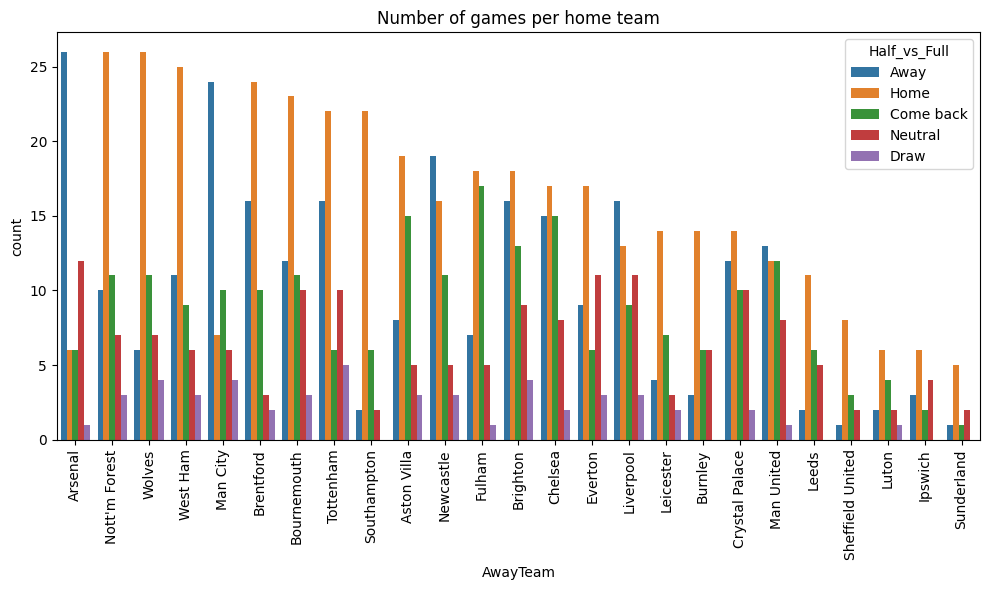

In [19]:
cow = games_with_half_time_goal.groupby('AwayTeam')['Half_vs_Full'].value_counts().sort_values(ascending=False)
# Convert the Series with MultiIndex to a DataFrame
cow_df = cow.reset_index(name='count')

# Plotting with explicit x, y, and hue parameters
plt.figure(figsize=(10, 6))
sns.barplot(data=cow_df, x='AwayTeam', y='count', hue='Half_vs_Full').set_title('Number of games per home team')
plt.xticks(rotation=90) # Rotate x-axis labels for better readability
plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show()

In [20]:
games_with_half_time_goal.groupby('HomeTeam')['Half_vs_Full'].value_counts()

HomeTeam  Half_vs_Full
Arsenal   Home            34
          Come back       12
          Neutral          7
          Away             2
          Draw             1
                          ..
Wolves    Away            19
          Home            17
          Come back       10
          Neutral          6
          Draw             2
Name: count, Length: 122, dtype: int64

In [21]:
home_trailing_ht = games_with_half_time_goal[games_with_half_time_goal['HalfT_leader'] == 'A']
home_trailing_and_won = home_trailing_ht[home_trailing_ht['FTR'] == 'H']
prob_home_win_when_trailing_ht = len(home_trailing_and_won) / len(home_trailing_ht) if len(home_trailing_ht) > 0 else 0

draw_ht = games_with_half_time_goal[games_with_half_time_goal['HalfT_leader'] == 'D']
home_win_when_draw_ht = draw_ht[draw_ht['FTR'] == 'H']
prob_home_win_when_draw_ht = len(home_win_when_draw_ht) / len(draw_ht) if len(draw_ht) > 0 else 0

away_trailing_ht = games_with_half_time_goal[games_with_half_time_goal['HalfT_leader'] == 'H']
away_trailing_and_won = away_trailing_ht[away_trailing_ht['FTR'] == 'A']
prob_away_win_when_trailing_ht = len(away_trailing_and_won) / len(away_trailing_ht) if len(away_trailing_ht) > 0 else 0

away_win_when_draw_ht = draw_ht[draw_ht['FTR'] == 'A']
prob_away_win_when_draw_ht = len(away_win_when_draw_ht) / len(draw_ht) if len(draw_ht) > 0 else 0

print(f"Probability of Home team winning when trailing at Half-Time: {prob_home_win_when_trailing_ht:.2%}")
print(f"Probability of Home team winning when drawing at Half-Time: {prob_home_win_when_draw_ht:.2%}")
print(f"Probability of Away team winning when trailing at Half-Time: {prob_away_win_when_trailing_ht:.2%}")
print(f"Probability of Away team winning when drawing at Half-Time: {prob_away_win_when_draw_ht:.2%}")

Probability of Home team winning when trailing at Half-Time: 12.90%
Probability of Home team winning when drawing at Half-Time: 40.91%
Probability of Away team winning when trailing at Half-Time: 8.25%
Probability of Away team winning when drawing at Half-Time: 30.68%


In [22]:
from scipy.stats import chi2_contingency

# Contingency table: did the HT leader hold on or did the result change?
contingency = pd.crosstab(
    games_with_half_time_goal['HalfT_leader'],
    games_with_half_time_goal['Changed']
)

chi2, p, dof, expected = chi2_contingency(contingency)

print(f"Chi-square statistic: {chi2:.4f}")
print(f"Degrees of freedom:   {dof}")
print(f"P-value:              {p:.6f}")

if p < 0.05:
    print("\nResult is statistically significant (p < 0.05).")
    print("Whether the HT leader holds on is NOT random — it depends on who is leading.")
else:
    print("\nResult is NOT statistically significant.")

Chi-square statistic: 126.4267
Degrees of freedom:   2
P-value:              0.000000

Result is statistically significant (p < 0.05).
Whether the HT leader holds on is NOT random — it depends on who is leading.


In [23]:
# Does being home or away affect comeback probability?
comeback_table = pd.crosstab(
    games_with_half_time_goal['HalfT_leader'],
    games_with_half_time_goal['Half_vs_Full'] == 'Come back'
)
comeback_table.columns = ['No comeback', 'Comeback']

chi2_cb, p_cb, dof_cb, _ = chi2_contingency(comeback_table)
print(f"Comeback chi-square p-value: {p_cb:.6f}")

Comeback chi-square p-value: 0.000000


## Conclusion

Our analysis of EPL matches where at least one goal was scored in the first half reveals several key insights into comebacks and match dynamics:

*   **Significant Lead Retention**: In approximately **64.8%** of these matches, the team leading at half-time ultimately won the match. This suggests that holding a lead at the break is a strong indicator of final victory.

*   **Comebacks are Common**: Despite the high lead retention, a substantial **35.2%** of matches saw the half-time leader *not* win, indicating a significant potential for shifts in momentum. Within this, **20.3%** of all analyzed matches resulted in a 'comeback' (a team losing at half-time going on to win).

*   **Home Advantage in Comebacks**: While both home and away teams achieve comebacks, home teams are slightly more likely to do so. Of all comebacks, **55.3%** were achieved by home teams, and **44.7%** by away teams. This translates to an overall probability of **11.23%** for a home team to achieve a comeback and **9.07%** for an away team in the games considered.

*   **Other Outcomes**: Beyond clear wins and comebacks, **14.9%** of games ended in a 'Neutral' outcome (leader at half-time, but full-time draw), and **4.7%** were draws at both half-time and full-time.

In essence, while leading at half-time offers a strong advantage in the EPL, teams that are trailing or drawing still have a considerable chance to change the game's outcome, with home teams showing a slightly higher propensity for dramatic reversals.



### Chi test conclusions

- 64.8% of games where a team led at half time ended with that team winning —
  the HT leader is a strong predictor of the final result.
- Comebacks occurred in ~20% of games where someone scored in the first half.
- Home teams accounted for 55.3% of all comebacks vs 44.7% for away teams.
- A chi-square test (p < 0.0001) confirms this home/away comeback difference
  is statistically significant — home advantage plays a real role in second-half reversals.
- Limitation: this analysis covers EPL seasons 2022–2025 only and does not
  account for scoreline margin, team quality, or match context.

### Calculating minimum odds needed

In [24]:
# Break-even odds with 5% stake tax
tax_rate = 0.15
stake = 100

# You only bet 95 after tax
effective_stake = stake * (1 - tax_rate)  # = 95

# For a bet at decimal odds O, you need:
# effective_stake * O > stake  (to profit)
# So: minimum odds to break even =
min_odds = stake / effective_stake
print(f"Break-even decimal odds: {min_odds:.4f}")  # 1.0526

# For YOUR finding (HT leader holds on 64.83% of the time):
prob = 0.4
fair_odds = 1 / prob
print(f"Fair decimal odds: {fair_odds:.4f}")       # 1.5423

# Odds needed to have an edge after tax
edge_odds = fair_odds / (1 - tax_rate)
print(f"Minimum odds needed for edge: {edge_odds:.4f}")  # 1.6235

Break-even decimal odds: 1.1765
Fair decimal odds: 2.5000
Minimum odds needed for edge: 2.9412
